
# Implementation of a Neural Network for Iris dataset classification

This notebook implements a multilayer neural network for classifying if students will get admitted using the Admission dataset.

The code is modularized into functions to facilitate understanding and step-by-step execution.

## Introduction <a name="introduction"></a>

In this lab we build a simple Neural Network, implementing every function from scratch.

The problem to be solved is the identification (*classification*) of the students that will be admitted, using the GRE (Graduate Record Examination, a test with the scale of 200–800 in 10-point increments) and the GPA (Grade Point Average, a summary of a student's academic performance on a 0.0 to 4.0 scale). We are also given the rank, which we interpret as the ranking of the applicant’s undergraduate institution.

We will follow a sequence of steps that align well with the process of building and validating a ML model:
- The first part does not have to do with the model but with the data preparation for modelling.
- Next we build the functions for the NN and training
- Finally the performance of the model is checked with the test data

## Importing libraries

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

SEED = 4836

## Load and preprocess data

### Reading the data

In [33]:
#read data from csv
path = None #r"C:\Users\pol12\Desktop\Universitat\MAMME\Statistical Learning\Parte 2 - Neural Nets & Trees\Task 1 Neural Nets\Admissions.csv"
filepath = "Admissions.csv"
if path:
    filepath = os.path.join(path, filepath)

admission_df = pd.read_csv(filepath)

print(admission_df.head())
print(admission_df.info())
selected_rows = [0, 1, 50, 51, 100, 101]
admission_df.iloc[selected_rows]

   admit  gre   gpa  rank
0      0  380  3.61     3
1      1  660  3.67     3
2      1  800  4.00     1
3      1  640  3.19     4
4      0  520  2.93     4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    int64  
 1   gre     400 non-null    int64  
 2   gpa     400 non-null    float64
 3   rank    400 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 12.6 KB
None


,admit,gre,gpa,rank
0,0,380,3.61,3
1,1,660,3.67,3
50,0,640,3.86,3
51,0,440,3.13,4
100,0,340,3.15,3
101,0,580,3.57,3


### Dataset verification

A standard step in the Data Analysis pipeline is to check the data, in order to detect possible wrong or problematic values such as missing data, outliers, mistakes (ex. negative length) etc.

While this is very context dependent a function to automate the checking is defined and applied below.

In [34]:
#Check the dataset to make sure no data is missing and Check the class labels
def verify_dataset(data):
  #if any of the rows have missing value return datas missing
  data_found = 1
  for each_column in data.columns:
    if data[each_column].isnull().any():
            print("Data missing in Column " + each_column)
            #if any rows are not missing return Dataset is complete. No missing value
            quit()
    if data_found == 1:
        print("Dataset is complete. No missing values. Ok")
    return

verify_dataset(admission_df)

Dataset is complete. No missing values. Ok


It is nice to have a first description of the variables.

In [35]:
# Set the correct variable types
admission_df["admit"] = admission_df["admit"].astype("category")
admission_df["rank"] = admission_df["rank"].astype("int")
# Print a summary of each variable
print(admission_df.describe(include="all"))

        admit         gre         gpa       rank
count   400.0  400.000000  400.000000  400.00000
unique    2.0         NaN         NaN        NaN
top       0.0         NaN         NaN        NaN
freq    273.0         NaN         NaN        NaN
mean      NaN  587.700000    3.389900    2.48500
std       NaN  115.516536    0.380567    0.94446
min       NaN  220.000000    2.260000    1.00000
25%       NaN  520.000000    3.130000    2.00000
50%       NaN  580.000000    3.395000    2.00000
75%       NaN  660.000000    3.670000    3.00000
max       NaN  800.000000    4.000000    4.00000


We can see how values for variable `gre` are always between 220 and 800, and the `gpa` values are between 2.26 and 4.0 so the range of all data is correct.

We can also look at a first visualization of what the variables look like:

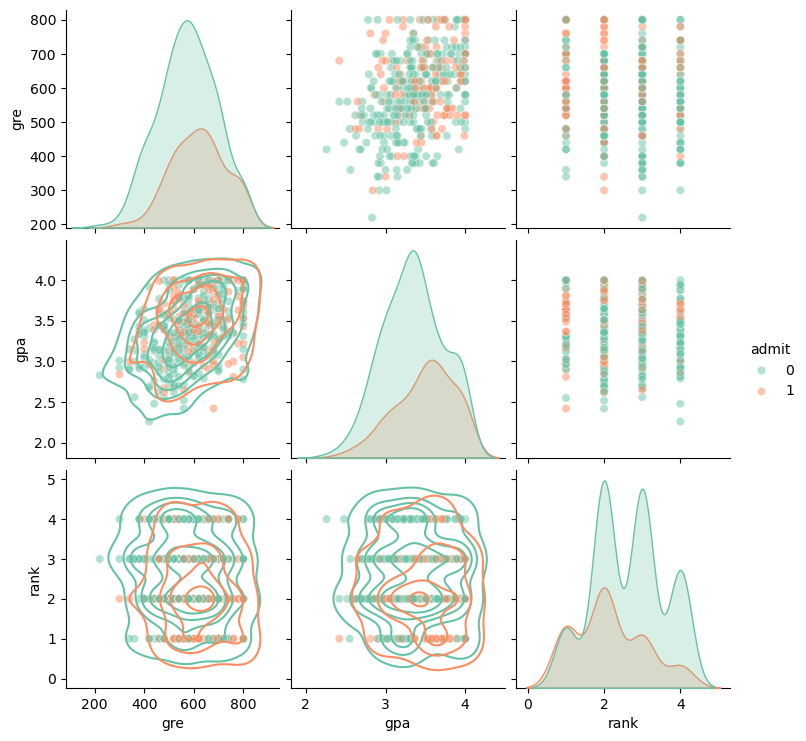

In [36]:
g = sns.pairplot(admission_df, hue="admit", kind="scatter", diag_kind="auto", palette="Set2", plot_kws=dict(alpha=0.5))
g.map_lower(sns.kdeplot, levels=6)

In the **admission dataset** the target variable consists of a binary variable, so we do not need to do one hot encoding. We simply use our target variable as it is, with 1 meaning the student has been admitted and 0 otherwise.

### Data normalization function

The training of many ML models, like ANNs, can be negatively affected by input features with different scales. Some of the problems this can yield are:
- Features with larger numerical ranges can dominate smaller ones, leading to biased weight updates in the model.
- Gradient-based optimization methods (like *gradient descent*) converge faster when input features are on a similar scale.
- Large values may lead to computational issues such as *vanishing or exploding gradients*.

This is typically achieved by transforming the data so that all features have comparable scales, ensuring they contribute equally to a machine learning model. We are going to use *column-wise normalization* in order to scale each feature independently to preserve relationships among variables. This is because the features represent measurements of the performance of each student, not unit vectors or directional data. This ensures that the relationships among features are maintained while preventing differences in scale from affecting the learning process.

We think it makes sense to normalize using standardization of the variables by centering them and setting variance to 1.

### Running the preprocessing steps

#### Data normalization

If column wise normalization is applied, it has to be done separately for train ans test sets
If one applies row wise normalization it can be done on all data.

In order to keep with the original lab we apply row-wise normalization

#### Selecting features and transforming dataframe into array

In [37]:
# Keep only selected features
X_set = admission_df[["gre", "gpa"]]
print(X_set.iloc[selected_rows])

X_set = X_set.to_numpy() # Change data from Pandas Dataframe to numpy array

     gre   gpa
0    380  3.61
1    660  3.67
50   640  3.86
51   440  3.13
100  340  3.15
101  580  3.57


In [38]:
# Normalize
mean = X_set.mean(axis=0)
print(f"mean: {mean}")
std = X_set.std(axis=0)
print(f"std: {std}")

X_set = (X_set - mean) / std
print(X_set[selected_rows])

mean: [587.7      3.3899]
std: [115.37205034   0.38009077]
[[-1.80026271  0.57907221]
 [ 0.62666824  0.73692924]
 [ 0.45331603  1.23680984]
 [-1.28020608 -0.68378404]
 [-2.14696713 -0.63116503]
 [-0.0667406   0.47383419]]


In [39]:
y = admission_df[["admit"]].to_numpy()
print(y[selected_rows])

[[0]
 [1]
 [0]
 [0]
 [0]
 [0]]


### Test-Training split function

Before we can train the model we will need to split the data in train and tests

In [40]:
def split_dataset_test_train(data,train_size):
  data = data.sample(frac=1).reset_index(drop=True)
  training_data = data.iloc[:int(train_size * len(data))].reset_index(drop=True)
  testing_data = data.iloc[int(train_size * len(data)):].reset_index(drop=True)
  return [training_data, testing_data]

#### Split the data

Now we will prepare our training and testing datasets. In order to do that, observe that we need to do the normalization with the training test (we save the mean and std from it), and then use that to normalize the test set. So, first we will split and then we will normalize. Observe that the target variable is the last column and the explanatory variables are all columns except the last one.

In [41]:
x_y = admission_df[["admit", "gre","gpa"]]


np.random.seed(SEED)

train_test_data = split_dataset_test_train(x_y,0.7)
# Variables are all except the last column
X_train = train_test_data[0].iloc[:, 1:].to_numpy()
X_test = train_test_data[1].iloc[:, 1:].to_numpy()

# Target variable is the last column
y_train = train_test_data[0].iloc[:,[0]].to_numpy()
y_test = train_test_data[1].iloc[:,[0]].to_numpy()

print(f"Training set counts for {train_test_data[0]['admit'].value_counts()}")
print(f"Test set counts for {train_test_data[1]['admit'].value_counts()}")
print("selected rows in training set")
print(X_train[selected_rows])
print(y[selected_rows])

Training set counts for admit
0    189
1     91
Name: count, dtype: int64
Test set counts for admit
0    84
1    36
Name: count, dtype: int64
selected rows in training set
[[560.     3.24]
 [680.     3.14]
 [600.     3.54]
 [720.     3.42]
 [480.     3.57]
 [520.     3.15]]
[[0]
 [1]
 [0]
 [0]
 [0]
 [0]]


In [42]:
### Normalize test and train sets separately

# If column wise normalization is applied, it has to be done separately for train ans test sets
def normalize(data, mean, std):
    data = (data - mean)/std
    return data

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

X_train = normalize(X_train, train_mean, train_std)
X_test = normalize(X_test, train_mean, train_std)

print(X_train[selected_rows])

[[-0.27542236 -0.42498616]
 [ 0.7834096  -0.67990502]
 [ 0.07752163  0.33977043]
 [ 1.13635359  0.03386779]
 [-0.98131034  0.41624608]
 [-0.62836635 -0.65441314]]


## Training process

The network is trained by a succession of forward and backward iteration steps, continuously adjusting the model parameters to minimize the error.

- **Forward propagation**: Computes the activations in each layer by applying weighted transformations and activation functions.
- **Loss computation**: Measures the difference between the predicted output and the actual target values.
- **Backward propagation**: Computes gradients by applying the chain rule to propagate the error backward through the network.
- **Weight update**: Adjusts the parameters using gradient descent or another optimization algorithm to reduce the loss in future iterations.

This process is repeated over multiple epochs until convergence or a stopping criterion is met.

### Activation functions

In [43]:
def sigmoid(z):
    #σ(z) = 1 / (1 + e^{-z})
    return 1 / (1 + np.exp(-z))





## Forward propagation

The network is trained  by a succession of forward and backward iteration steps
Forward propagation computes activations in each layer of the network.

1. **Hidden layer**:

Preactivaciones:

$$ z^{(1)}_{1} = X W^{(1)}_{1} + b^{(1)}_{1} $$
$$ z^{(1)}_{2} = X W^{(1)}_{2} + b^{(1)}_{2} $$


Activaciones
$$ a^{(1)}_{1} = \sigma(z^{(1)}_{1}) = \frac{1}{1 + e^{-z^{(1)}_{1}}} $$
$$ a^{(1)}_{2} = \sigma(z^{(1)}_{2}) = \frac{1}{1 + e^{-z^{(1)}_{2}}} $$

2. **Output layer**:
$$ z^{(2)} = a^{(1)}_{1} W^{(2)}_{1} + a^{(1)}_{2} W^{(2)}_{2}  + b^{(2)} $$

$$ \hat{y} = \sigma(z^{(2)}) = \frac{1}{1 + e^{-z^{(2)}}} $$

Where $\sigma(x)$ is the sigmoid function and softmax converts the outputs into probabilities.

And $A_h$ and $A_o$ are respectively the hideen layer and output layer activations.

In [44]:
def forward_propagation(X, W1, b1, W2, b2):
    # Hidden layer
    Z_h = np.dot(X, W1) + b1
    A_h = sigmoid(Z_h)

    # Output layer
    Z_o = np.dot(A_h, W2) + b2
    y_hat = sigmoid(Z_o)

    cache = {
        "Z_h": Z_h,
        "A_h": A_h,
        "z_o": Z_o,
        "y_hat": y_hat
    }
    return A_h, y_hat, cache


### Loss Function

binary cross-entropy:
$L(y, \hat{y}) = − [y log(\hat{y}) + (1 − y) log(1 − \hat{y})]$

In [45]:
def loss_function(Y, y_hat):
    loss = -(Y * np.log(y_hat) + (1 - Y) * np.log(1 - y_hat))
    return loss


## Backpropagation

The error propagates backward to adjust weights using gradient descent.

1. **Error in the output layer**:

$$ \delta_o = \hat{y} - Y $$

2. **Error in the hidden layer**:

$$ \delta_h = (\delta_o W_1^T) \cdot \sigma'(Z_h) $$

3. **Gradients to update weights**:

$$ W^{(2)} \gets W^{(2)} - \eta (A_h^T \delta_o) $$
$$ b^{(2)} \gets b^{(2)} - \eta \sum \delta_o $$

$$ W^{(1)} \gets W^{(1)} - \eta (X^T \delta_h) $$
$$ b^{(1)} \gets b^{(1)} - \eta \sum \delta_h $$

Where $ \sigma'(x) $ is the derivative of the activation function, here, the sigmoid function.


In [46]:

def sigmoid_deriv(a):
    return a * (1 - a)

def backpropagation(X, Y, A_h, y_hat, W2):
    # Error output layer
    delta_o = y_hat - Y

    # Error hidden layer 
    dcost_dah = np.dot(delta_o, W2.T)
    delta_h = dcost_dah * sigmoid_deriv(A_h)

    return delta_o, delta_h


In [139]:

def update_weights(X, A_h, delta_o, delta_h, W1, b1, W2, b2, learning_rate):
    # Gradient output layer
    dcost_dW_o = np.dot(A_h.T, delta_o)
    dcost_db_o = np.sum(delta_o, axis=0)

    W2 -= learning_rate * dcost_dW_o
    b2 -= learning_rate * dcost_db_o

    # Gradient hidden layer
    dcost_dW_h = np.dot(X.T, delta_h)
    dcost_db_h = np.sum(delta_h, axis=0)

    W1 -= learning_rate * dcost_dW_h
    b1 -= learning_rate * dcost_db_h

    gradients = {
        "dW2": dcost_dW_o,
        "db2": dcost_db_o,
        "dW1": dcost_dW_h,
        "db1": dcost_db_h   
    }
    return W1, b1, W2, b2, gradients



## Initialization of weights and bias

Before training the network, weights and biases must be randomly initialized.
For the hidden layer ($ W_0 $, $ b_0 $) and the output layer ($ W_1 $, $ b_1 $):

$$ W_0 \in \mathbb{R}^{n_{input} \times n_{hidden}}, \quad b_0 \in \mathbb{R}^{1 \times n_{hidden}} $$
$$ W_1 \in \mathbb{R}^{n_{hidden} \times n_{output}}, \quad b_1 \in \mathbb{R}^{1 \times n_{output}} $$

Weights are randomly initialized  to break symmetry in learning.


In [48]:
def initialize_network(input_size, hidden_size, output_size):
    # Initialize the weights and biases of a neural network.
    W1 = np.random.uniform(-0.2, 0.2, (input_size, hidden_size))  # Input -> Hidden weights
    b1 = np.random.uniform(-0.05, 0.05, hidden_size)  # Hidden bias   

    W2 = np.random.uniform(-0.2, 0.2, (hidden_size, output_size))   # Hidden -> Output weights
    b2 = np.random.uniform(-0.05, 0.05, output_size)  # Output bias
    return [W1, b1, W2, b2]



## Neural network training

After setting the weights to their initial (usually random) values, the neural network is trained going through several iterations with all the data (*epochs*) where the output is computed by forward propagation and the difference among the output and the is true value is used to adjust the weights by backpropagating the error.

The process stops when convergence or a certain number of iterations is reached.


In [54]:
def train_neural_network(X_train, Y_train, epochs, learning_rate, batch_size, params):
    W1, b1, W2, b2 = params  # Unpack initial parameters
    num_samples = X_train.shape[0]
    
    # Calculate number of batches
    num_batches = num_samples // batch_size
    if num_samples % batch_size != 0:
        num_batches += 1  # Include last batch if not evenly divisible

    loss_history = []  # Track loss over epochs

    for epoch in range(epochs):
        for batch_idx in range(num_batches):
            # Define batch range
            batch_start = batch_idx * batch_size
            batch_end = min(batch_start + batch_size, num_samples)
            X_batch = X_train[batch_start:batch_end]
            Y_batch = Y_train[batch_start:batch_end]

            # Forward Propagation
            A_h, A_o, cache = forward_propagation(X_batch, W1, b1, W2, b2)
            loss = loss_function(Y_batch, A_o)

            # Backpropagation
            delta_o, delta_h = backpropagation(X_batch, Y_batch, A_h, A_o, W2)

            # Weight update
            W1, b1, W2, b2, gradients = update_weights(X_batch, A_h, delta_o, delta_h, W1, b1, W2, b2, learning_rate)

        # Compute loss every 100 epochs
        if epoch % 100 == 0:
            _, A_o, _ = forward_propagation(X_train, W1, b1, W2, b2)  # Evaluate full dataset
            loss = -np.mean(Y_train * np.log(A_o + 1e-9) + (1 - Y_train) * np.log(1 - A_o + 1e-9))   # Avoid log(0)

            loss_history.append(loss)
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return [W1, b1, W2, b2], loss_history  # Return trained parameters and loss history

# Calculus


In [146]:

W1 = np.array([
        [-0.0520 , 0.0089],
        [-0.0197 , 0.0579]
    ])
b1 = np.array([0.0467, -0.0201])
W2 = np.array([[0.0444], [-0.1927]])
b2 = np.array([-0.0013])

X_calc= np.array([0.825, 0.9175])
Y_calc = 1

for i in range(2):
    print(f"Iteration {i+1}")
    A_h, A_o, cache = forward_propagation(X_calc, W1, b1, W2, b2)
    print(f"forward propagation output:")
    for key, value in cache.items():
        print(f"{key}: {value}")

    loss = loss_function(Y_calc, A_o)
    print(f"loss: {loss}")
    delta_o, delta_h = backpropagation(X_calc, Y_calc, A_h, A_o, W2)
    print(f"backpropagation output:")
    print(f"delta_o: {delta_o}, {delta_o.shape}")
    print(f"delta_h: {delta_h}, {delta_h.shape}")

    X_row = X_calc.reshape(1, -1)     # Shape (1, input_features)
    Ah_row = A_h.reshape(1, -1)       # Shape (1, 2)
    do_row = delta_o.reshape(1, -1)   # Shape (1, 1)
    dh_row = delta_h.reshape(1, -1)   # Shape (1, 2)
    W1, b1, W2, b2, gradients = update_weights(X_row, Ah_row, do_row, dh_row, W1, b1, W2, b2, learning_rate = 0.1)
    print(f"Updated weights and biases:")
    print(f"W1: {W1}")
    print(f"b1: {b1}")
    print(f"W2: {W2}")
    print(f"b2: {b2}")
    print(f"Gradients:")
    for key, value in gradients.items():
        print(f"{key}: {value}")


Iteration 1
forward propagation output:
Z_h: [-0.01427475  0.04036575]
A_h: [0.49643137 0.51009007]
z_o: [-0.0775528]
y_hat: [0.48062151]
loss: [0.7326752]
backpropagation output:
delta_o: [-0.51937849], (1,)
delta_h: [-0.00576481  0.02501087], (2,)
Updated weights and biases:
W1: [[-0.0515244   0.0068366 ]
 [-0.01917108  0.05560525]]
b1: [ 0.04727648 -0.02260109]
W2: [[ 0.07018358]
 [-0.16620702]]
b2: [0.05063785]
Gradients:
dW2: [[-0.25783578]
 [-0.26492981]]
db2: [-0.51937849]
dW1: [[-0.00475597  0.02063397]
 [-0.00528921  0.02294747]]
db1: [-0.00576481  0.02501087]
Iteration 2
forward propagation output:
Z_h: [-0.01282062  0.03405693]
A_h: [0.49679489 0.50851341]
z_o: [0.00098619]
y_hat: [0.50024655]
loss: [0.69265421]
backpropagation output:
delta_o: [-0.49975345], (1,)
delta_h: [-0.00876826  0.02075961], (2,)
Updated weights and biases:
W1: [[-0.05080102  0.00512394]
 [-0.01836659  0.05370056]]
b1: [ 0.04815331 -0.02467705]
W2: [[ 0.09501107]
 [-0.14079389]]
b2: [0.10061319]
Grad

# Training the network in practice

## Initialize the network and hyperparameters

Setting the weights defines the architechture of the network (assuming full connectivity).

We set:

- input layer: 2 nodes (we use 2 features to train the network)
- hidden layer: 2 nodes
- output layer: 1 nodes

Additionally we must set the values of the parameters that will be used for training

learning_rate = 0.01
batch_size = 10
epochs = 1000


In [50]:

np.random.seed(SEED)
input_size=X_train.shape[1]
hidden_size=2
output_size=1
my_params = initialize_network(input_size, hidden_size, output_size)
my_params

[array([[ 0.14804165,  0.11534655],
        [ 0.15887509, -0.06122428]]),
 array([-0.04176294, -0.0228326 ]),
 array([[0.02967095],
        [0.18203228]]),
 array([-0.04169278])]

In [51]:
learning_rate = 0.01
batch_size = 10
epochs = 1000
loss_history = []  # Store errors during training

In [52]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print()

(280, 2)
(280, 1)
(120, 2)
(120, 1)



## Train the network

Given the data, the parameters and the hyperparameters we can call the main training function.

In [55]:
trainedNet, loss_history = train_neural_network (X_train=X_train, Y_train=y_train, 
                                  epochs=epochs, learning_rate=learning_rate, batch_size=batch_size,
                                  params=my_params)

Epoch 0, Loss: 0.6325
Epoch 100, Loss: 0.6085
Epoch 200, Loss: 0.6066
Epoch 300, Loss: 0.6058
Epoch 400, Loss: 0.6052
Epoch 500, Loss: 0.6049
Epoch 600, Loss: 0.6047
Epoch 700, Loss: 0.6045
Epoch 800, Loss: 0.6044
Epoch 900, Loss: 0.6044


### Check model performance

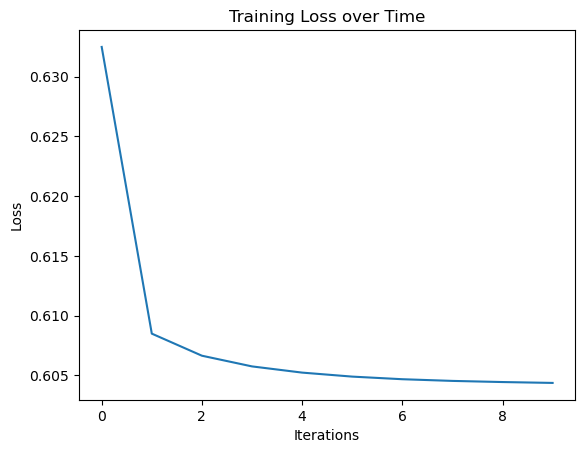

In [56]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss over Time")
plt.show()

### Evaluate network on test data

In [106]:
def evaluation(params, tst_set):
  w1 = params[0]
  bh = params[1]
  w2 = params[2]
  bo = params[3]

  # First layer propagation
  zh = np.dot(tst_set, w1) + bh
  layer1 = sigmoid(zh)

  # Second layer propagation
  zo = np.dot(layer1, w2) + bo
  layer2 = sigmoid(zo)

  return (layer2 > 0.5).astype(int)#

y_pred = evaluation(trainedNet, X_test)
y_pred.flatten()



array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:

print(y_test.shape)
print(pd.Series(y_test.flatten()).value_counts())

print(y_pred.shape)
print(pd.Series(y_pred.flatten()).value_counts())


(120, 1)
0    84
1    36
Name: count, dtype: int64
(120, 1)
0    120
Name: count, dtype: int64


In [94]:
actual = pd.Categorical(y_test.flatten(), categories=[0, 1])
predicted = pd.Categorical(y_pred.flatten(), categories=[0, 1])

ct = pd.crosstab(actual, predicted, rownames=['Actual'], colnames=['Predicted'], dropna=False)

print(ct)

Predicted   0  1
Actual          
0          84  0
1          36  0


In [119]:
from sklearn.metrics import confusion_matrix, classification_report

# Generate the matrix
cm = confusion_matrix(y_test.flatten(), y_pred.flatten())
print("Confusion Matrix:")
print(cm)

# Get detailed metrics (Precision, Recall, F1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Confusion Matrix:
[[84  0]
 [36  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      1.00      0.82        84
           1       0.00      0.00      0.00        36

    accuracy                           0.70       120
   macro avg       0.35      0.50      0.41       120
weighted avg       0.49      0.70      0.58       120



[[84  0]
 [36  0]]


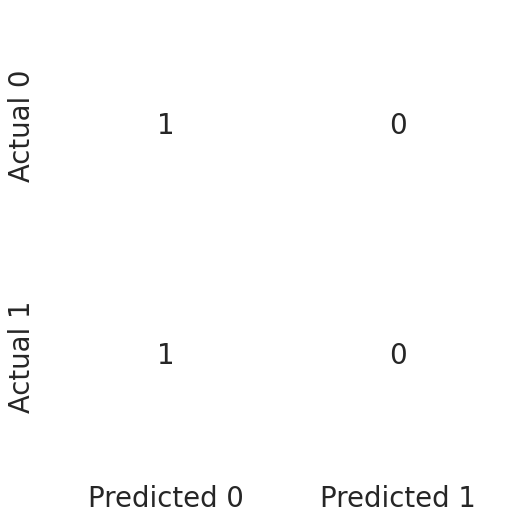

In [121]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print(cm)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


import seaborn as sns
from matplotlib.colors import ListedColormap


df_cm = pd.DataFrame(cm_norm, index = ['Actual 0', 'Actual 1'],
                  columns = ['Predicted 0', 'Predicted 1'])

plt.figure(figsize = (6,6))

with sns.axes_style('white'):
    sns.heatmap(df_cm,
                cbar=False,
                square=False,
                annot=True,
                annot_kws={"size": 20},
                cmap=ListedColormap(['white']),
                linewidths=0.5)
    sns.set(font_scale=1.8)